# Intelligent Cybersecurity Assistant (Rebuilt)

This notebook is rebuilt from scratch into 5 simple stages:

1. Detection (Hybrid Model): LSTM-style + CNN-style + Random Forest ensemble
2. Why Hybrid: combines temporal, pattern, and tabular perspectives
3. Correlation Engine: groups alert bursts into coordinated events
4. Reasoning Layer: explains likely attack type, severity, and response
5. Final Output: actionable incident statements, not raw alerts

In [1]:
from pathlib import Path
import sys
import importlib

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import intelligent_cyber_assistant as ica
importlib.reload(ica)
run_intelligent_ids_pipeline = ica.run_intelligent_ids_pipeline

data_path = project_root / 'data' / 'processed' / 'clean_data.csv'
print(f'Using dataset: {data_path}')

Using dataset: c:\Users\JIANA\Downloads\intrusion detection\intrusion_project\data\processed\clean_data.csv


In [2]:
result = run_intelligent_ids_pipeline(
    str(data_path),
    sample_size=12000,
    use_llm=True,
    llm_model='gpt-4o-mini',
)

print('=== Stage 1: Detection (Hybrid) ===')
print(f"Samples tested: {result['total_samples_tested']}")
print(f"Attack predictions: {result['attack_predictions']}")
print(f"ROC-AUC: {result['metrics']['roc_auc']}")

print('\n=== Stage 3: Correlation Engine ===')
print(f"Coordinated events found: {result['correlated_events']}")

=== Stage 1: Detection (Hybrid) ===
Samples tested: 2400
Attack predictions: 1609
ROC-AUC: 0.9827

=== Stage 3: Correlation Engine ===
Coordinated events found: 193


In [3]:
print('=== Stage 4 + 5: Reasoning + Final Actionable Output ===')

if not result['final_outputs']:
    print('No attack events to explain in this run.')
else:
    for item in result['final_outputs'][:5]:
        print('-' * 80)
        print(f"Event ID: {item['event_id']}")
        print(f"Attack Type: {item['attack_type']}")
        print(f"Source IP/Entity: {item.get('source_ip', 'unknown-source')}")
        print(f"Severity: {item['severity']}")
        print(f"Confidence: {item['confidence']}")
        print(f"LLM Used: {item['llm_used']}")
        print(f"Incident: {item.get('incident_statement', 'n/a')}")
        print(f"Reasoning: {item['reason']}")
        print(f"Recommended Action: {item['recommended_action']}")

=== Stage 4 + 5: Reasoning + Final Actionable Output ===
--------------------------------------------------------------------------------
Event ID: EVT-0001
Attack Type: Flood/DoS-like Activity
Source IP/Entity: entity-006941
Severity: Medium
Confidence: 0.620
LLM Used: no
Incident: Multiple suspicious dns activities from source entity-006941 observed between sample 11 and 16.
Reasoning: This appears to be flood/dos-like activity due to repeated suspicious dns behavior in a short window with confidence 0.62.
Recommended Action: Apply temporary rate limits, challenge suspicious sessions, and notify SOC channel
--------------------------------------------------------------------------------
Event ID: EVT-0002
Attack Type: Reconnaissance Activity
Source IP/Entity: entity-581893
Severity: Low
Confidence: 0.620
LLM Used: no
Incident: Multiple suspicious dns activities from source entity-581893 observed between sample 19 and 21.
Reasoning: This appears to be reconnaissance activity due to re

## Model Accuracy Comparison

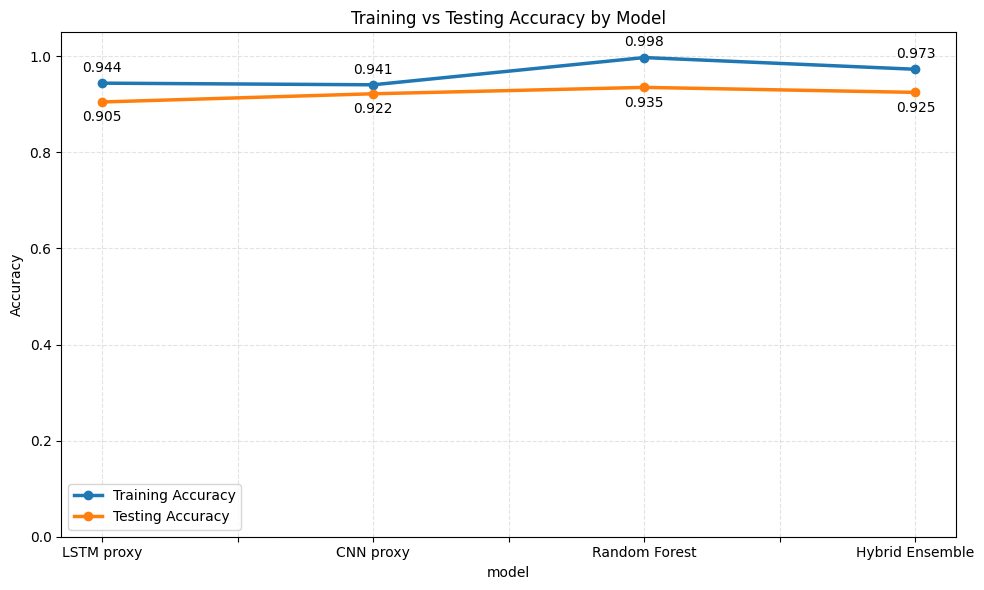

                 train_accuracy  test_accuracy
model                                         
LSTM proxy               0.9442         0.9050
CNN proxy                0.9408         0.9221
Random Forest            0.9975         0.9354
Hybrid Ensemble          0.9731         0.9250


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame(result['model_accuracy']).set_index('model')
comparison_df = comparison_df[['train_accuracy', 'test_accuracy']]

fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(kind='line', marker='o', linewidth=2.5, ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Testing Accuracy by Model')
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(['Training Accuracy', 'Testing Accuracy'])

for x_pos, model_name in enumerate(comparison_df.index):
    train_val = comparison_df.loc[model_name, 'train_accuracy']
    test_val = comparison_df.loc[model_name, 'test_accuracy']
    ax.annotate(f'{train_val:.3f}', (x_pos, train_val), textcoords='offset points', xytext=(0, 8), ha='center')
    ax.annotate(f'{test_val:.3f}', (x_pos, test_val), textcoords='offset points', xytext=(0, -14), ha='center')

plt.tight_layout()
plt.show()

print(comparison_df.to_string())